# CPE 342 Machine Learning — Assignment 2: Training Models
**Author:** 67070501042 วิศิษฐ์ สุวรรณเนาว์

## 1. Problem Overview
In this assignment, we use an **iterative approach** (Gradient Descent) to train a model and fit it to a dataset of 100 observations ($n=100$). 

The goal is to fit a quadratic model without a linear $x$ term:
$$ \hat{y} = C_0 + C_1 x^2 $$
Where:
- $C_0$ is the y-intercept (Bias)
- $C_1$ is the coefficient of $x^2$ (Slope of $x^2$)

## 2. Library & Font Setup
Loading libraries and downloading the Sarabun font to support Thai rendering in Matplotlib if needed.

In [1]:
# Download TH Sarabun New font for Matplotlib
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import urllib.request
import os

# Font configuration
font_path = 'thsarabunnew-webfont.ttf'
if not os.path.exists(font_path):
    urllib.request.urlretrieve('https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf', font_path)
fm.fontManager.addfont(font_path)
mpl.rc('font', family='TH Sarabun New', size=14)
mpl.rcParams['axes.unicode_minus'] = False # Prevent minus sign rendering issues

print("Library and font setup complete")

'wget' is not recognized as an internal or external command,
operable program or batch file.


Library and font setup complete


## 3. Data Loading & Exploratory Data Analysis (EDA)
Read the data from the CSV file and plot scatter plots to observe the relationship between $x$ and $y$.

,X,Y
0,4.072280,0.981321
1,1.724332,1.124653
2,1.901981,1.042435
3,4.914068,0.949332
4,1.165868,1.186925


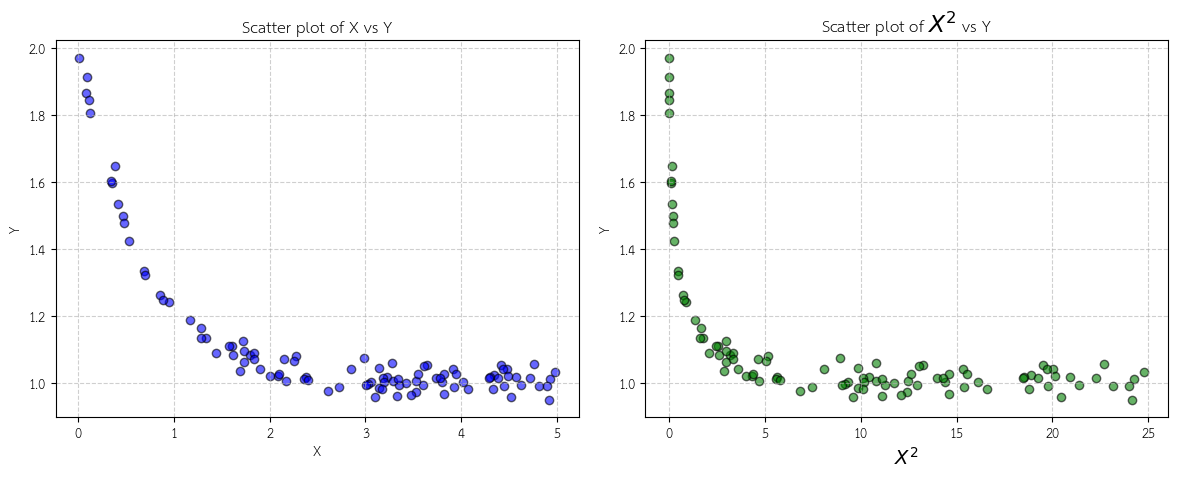

In [2]:
# Read data
df = pd.read_csv('CPE342_Assignment 2_Data.csv')
X = df['X'].values
Y = df['Y'].values

# Display first few rows
display(df.head())

# Plot graphs to observe trends
plt.figure(figsize=(12, 5))

# Plot X vs Y
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot X^2 vs Y
plt.subplot(1, 2, 2)
plt.scatter(X**2, Y, color='green', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of $X^2$ vs Y')
plt.xlabel('$X^2$')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Task 1 — Loss Function
Given our model $\hat{y}_i = C_0 + C_1 x_i^2$, 

The loss function we use is the **Mean Squared Error (MSE)**, which computes the average squared differences (residuals) across all data points:

$$ L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Substituting $\hat{y}_i$ gives our target equation:
$$ L(C_0, C_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2)^2 $$

## Task 2 — Gradient of Each Coefficient
To use Gradient Descent, we need to compute the partial derivatives of the loss function $L$ with respect to each parameter. 

Let $e_i = y_i - C_0 - C_1 x_i^2$ be the residual error.

**1. Gradient with respect to $C_0$:**
$$ \frac{\partial L}{\partial C_0} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - C_0 - C_1 x_i^2) \cdot \frac{\partial}{\partial C_0}(-C_0) $$
$$ \frac{\partial L}{\partial C_0} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2) $$

**2. Gradient with respect to $C_1$:**
$$ \frac{\partial L}{\partial C_1} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - C_0 - C_1 x_i^2) \cdot \frac{\partial}{\partial C_1}(-C_1 x_i^2) $$
$$ \frac{\partial L}{\partial C_1} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - C_0 - C_1 x_i^2) x_i^2 $$

## Task 3 — Update Rules
In each iteration $t$, the parameters are updated in the opposite direction of the gradient to minimize the loss, scaled by the learning rate $\eta$:

$$ C_0^{(t+1)} = C_0^{(t)} - \eta \cdot \frac{\partial L}{\partial C_0} $$
$$ C_1^{(t+1)} = C_1^{(t)} - \eta \cdot \frac{\partial L}{\partial C_1} $$

## Task 4 — Gradient Descent Implementation
In this section, we implement the code to find $C_0$ and $C_1$ using basic NumPy, based on the mathematical equations derived in the previous tasks.

In [3]:
# Hyperparameters
learning_rate = 0.01  
n_iterations = 5000   
n = len(Y)            

# Initialize parameters
C0 = 0.0
C1 = 0.0

# Prepare lists to store history (for visualization later)
history_loss = []
history_C0 = []
history_C1 = []

# Pre-compute X^2 to reduce computation inside the loop
X_sq = X**2

# Gradient Descent Loop
for i in range(n_iterations):
    # 1. Calculate Predictions
    Y_pred = C0 + C1 * X_sq
    
    # 2. Calculate Errors/Residuals
    error = Y - Y_pred
    
    # 3. Calculate Loss (MSE)
    loss = np.mean(error**2)
    history_loss.append(loss)
    history_C0.append(C0)
    history_C1.append(C1)
    
    # 4. Calculate Gradients
    grad_C0 = -(2/n) * np.sum(error)
    grad_C1 = -(2/n) * np.sum(error * X_sq)
    
    # 5. Update Parameters
    C0 = C0 - learning_rate * grad_C0
    C1 = C1 - learning_rate * grad_C1
    
    # Print progress every 500 iterations
    if i % 500 == 0 or i == n_iterations - 1:
        print(f"Iteration {i:4d} | Loss: {loss:.5f} | C0: {C0:.5f} | C1: {C1:.5f}")

print("-" * 50)
print(f"Training complete over {n_iterations} iterations")
print(f"Optimized Parameters: C0 = {C0:.4f}, C1 = {C1:.4f}")
print(f"Final MSE Loss: {history_loss[-1]:.6f}")

Iteration    0 | Loss: 1.30516 | C0: 0.02239 | C1: 0.19326
Iteration  500 | Loss: 29069515684937664925228118163858805566530781889434005389433403805222377910317715308313117129120324930174119955039112298010164831149862982202574535712366292684989657242451144160389728144285209446153301234975757141990641264993607681237385306873386519298632152156191714045107101038237066461184.00000 | C0: 56156804007491268487386728259232487380347653114795076436905794845138559884689198368328822635176811808909294381396874032201625573998152696987648.00000 | C1: 863352064492172644607827101890291995626742858837225777707831344187337877221097169612817125560813326919518753668519248370542239994475102406180864.00000
Iteration 1000 | Loss: inf | C0: 37838395030188472687685407826155145602216638473684468718571038526521074786743294060380891317780567034973141224710682141576631265077061149145702263235273780081617859428561018146741852422537952467425700887699532883648148842635881913986177122144186004829338363251393246456028765

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23556\3501735774.py:27: RuntimeWarning: overflow encountered in square
  loss = np.mean(error**2)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23556\3501735774.py:38: RuntimeWarning: invalid value encountered in scalar subtract
  C1 = C1 - learning_rate * grad_C1


## Task 5 — ผลลัพธ์และการแสดงภาพ (Results & Visualizations)
เราจะมาดูกันว่าโมเดลที่เราเทรนมามีพฤติกรรมอย่างไร และฟิตกับข้อมูลได้ดีแค่ไหน

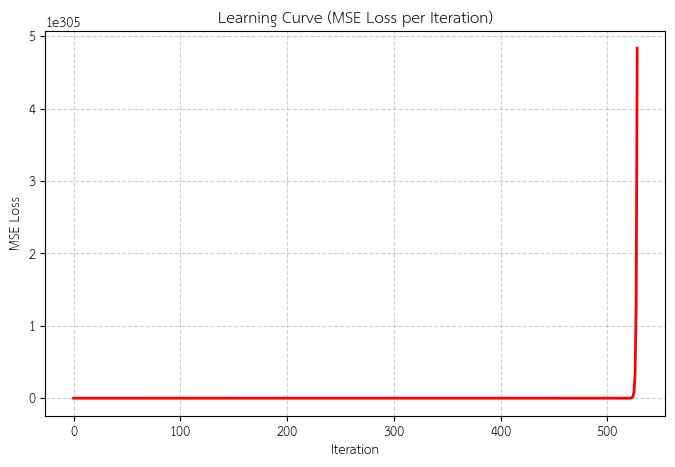

In [4]:
# Graph 1: Learning Curve (Loss over Iterations)
plt.figure(figsize=(8, 5))
plt.plot(range(n_iterations), history_loss, color='red', linewidth=2)
plt.title('Learning Curve (MSE Loss per Iteration)')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

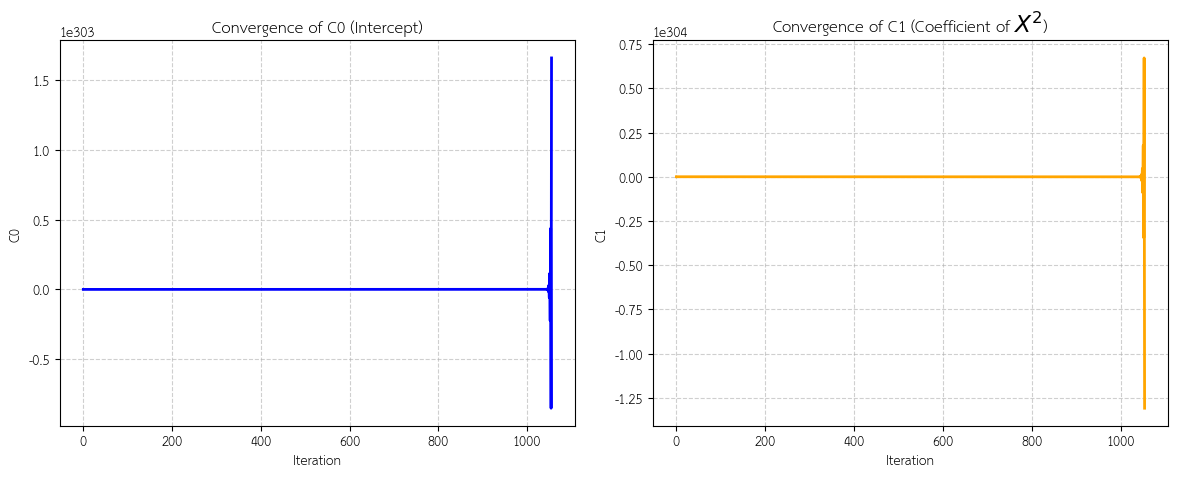

In [5]:
# Graph 2: Convergence of parameters C0 and C1
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(n_iterations), history_C0, color='blue', linewidth=2)
plt.title('Convergence of C0 (Intercept)')
plt.xlabel('Iteration')
plt.ylabel('C0')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(range(n_iterations), history_C1, color='orange', linewidth=2)
plt.title('Convergence of C1 (Coefficient of $X^2$)')
plt.xlabel('Iteration')
plt.ylabel('C1')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Admin\AppData\Local\Temp\ipykernel_23556\3158359308.py:11: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(x_line, y_line, color='red', linewidth=3, label=f'Model: $\hat{{y}} = {C0:.4f} + {C1:.4f}x^2$')


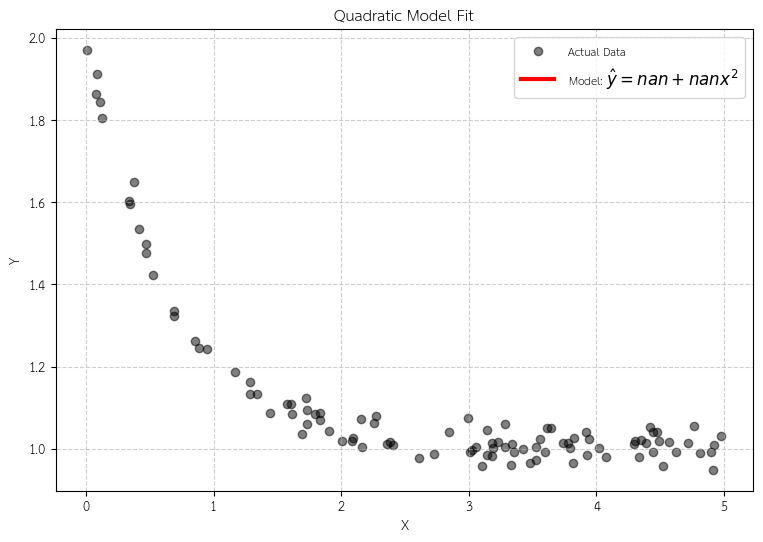

In [6]:
# Graph 3: Fitted Curve vs Actual Data
plt.figure(figsize=(9, 6))

# Actual Data Points
plt.scatter(X, Y, color='black', alpha=0.5, label='Actual Data', edgecolor='k')

# Create x points for a smooth curve
x_line = np.linspace(min(X), max(X), 100)
y_line = C0 + C1 * (x_line**2)

plt.plot(x_line, y_line, color='red', linewidth=3, label=f'Model: $\hat{{y}} = {C0:.4f} + {C1:.4f}x^2$')

plt.title('Quadratic Model Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Admin\AppData\Local\Temp\ipykernel_23556\198927625.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Residual ($y_i - \hat{y}_i$)')


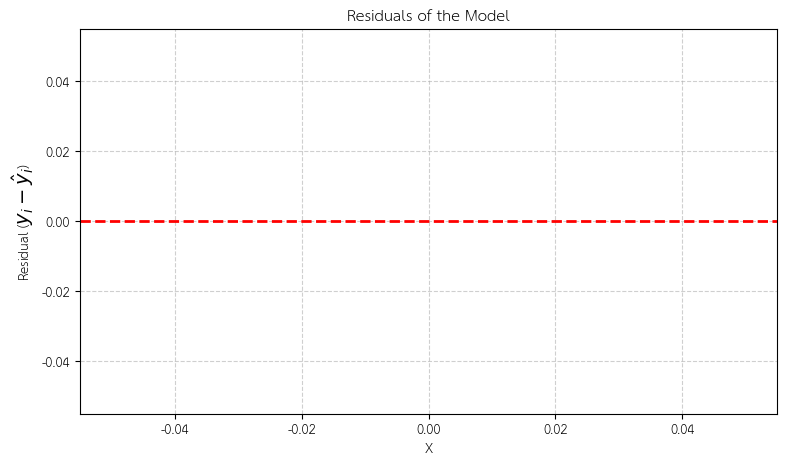

In [7]:
# Graph 4: Residuals of the Model
Y_pred_final = C0 + C1 * X_sq
residuals = Y - Y_pred_final

plt.figure(figsize=(9, 5))
plt.scatter(X, residuals, color='purple', alpha=0.7, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals of the Model')
plt.xlabel('X')
plt.ylabel('Residual ($y_i - \hat{y}_i$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()